### **Import library**

In [2]:
from sklearn import datasets
from sklearn.preprocessing import LabelEncoder

### **Load dataset**

In [4]:
import pandas as pd
df = pd.read_csv("Student_Performance_2026.csv")

# diabetes = datasets.load_diabetes()

In [4]:
df

,student_ID,Age,Gender,daily_screen_time_hours,social_media_hours,online_study_hours,gaming_hours,sleep_hours,attendance_percentage,offline_study_hours,previous_sem_CGPA,current_sem_CGPA
0,S011,23,Female,6.2,2.5,3.8,1.2,7.1,79,2.6,7.74,7.94
1,S012,24,Female,4.9,2.0,5.1,1.0,8.3,79,2.6,7.72,7.92
2,S013,18,Female,7.9,3.2,2.1,1.6,7.1,68,2.3,6.67,6.87
3,S014,17,Male,10.0,4.0,0.0,2.0,5.9,63,2.1,6.10,6.30
4,S015,23,Female,7.7,3.1,2.3,1.5,6.4,69,2.3,6.77,6.97
...,...,...,...,...,...,...,...,...,...,...,...,...
541,S552,17,Male,4.1,1.6,5.9,0.8,8.2,78,2.6,7.63,7.83
542,S553,24,Female,6.4,2.6,3.6,1.3,7.5,79,2.6,7.74,7.94
543,S554,17,Male,8.3,3.3,1.7,1.7,6.0,58,1.9,5.62,5.82
544,S555,21,Female,9.8,3.9,0.2,2.0,6.3,64,2.2,6.29,6.49


### **Create X and Y data matrices**

In [7]:
X = df.drop("current_sem_CGPA", axis=1)
X = X.drop("student_ID", axis=1)
X["Gender"] = LabelEncoder().fit_transform(X["Gender"])
X = X.drop("previous_sem_CGPA", axis=1)

Y = df["current_sem_CGPA"]

## **Data split**

### **Import library**

In [8]:
from sklearn.model_selection import train_test_split

### **Perform 80/20 Data split**

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

### **Data dimension**

In [10]:
X_train.shape, Y_train.shape

((436, 9), (436,))

In [11]:
X_test.shape, Y_test.shape

((110, 9), (110,))

## **Linear Regression Model**

### **Import library**

In [12]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

### **Build linear regression**

#### Defines the regression model

In [13]:
model = linear_model.LinearRegression()
df.select_dtypes(include=['object']).head()


/tmp/ipykernel_439836/211772757.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).head()


,student_ID,Gender
0,S011,Female
1,S012,Female
2,S013,Female
3,S014,Male
4,S015,Female


#### Build training model

In [14]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Apply trained model to make prediction (on test set)

In [15]:
Y_pred = model.predict(X_test)

## **Prediction results**

### **Print model performance**

In [16]:
print('Coefficients:', model.coef_)
print('Intercept:', model.intercept_)
print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y_test, Y_pred))
print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y_test, Y_pred))

Coefficients: [ 2.01011374e-04 -1.25872306e-03  9.40556844e-03 -3.50062470e-02
 -9.40556844e-03 -1.90918554e-02 -2.13988235e-04  8.64545662e-02
  4.11735762e-01]
Intercept: 0.11206536820414925
Mean squared error (MSE): 0.00
Coefficient of determination (R^2): 1.00


### **String formatting**

By default r2_score returns a floating number ([more details](https://docs.scipy.org/doc/numpy-1.13.0/user/basics.types.html))

In [17]:
r2_score(Y_test, Y_pred)

0.9994697442721052

We will be using the modulo operator to format the numbers by rounding it off.

In [18]:
'%f' % 0.523810833536016

'0.523811'

We will now round it off to 3 digits

In [19]:
'%.3f' % 0.523810833536016

'0.524'

We will now round it off to 2 digits

In [20]:
'%.2f' % 0.523810833536016

'0.52'

## **Scatter plots**

### **Import library**

In [22]:
import seaborn as sns

### **Make scatter plot**

#### The Data

In [23]:
Y_test

464    7.25
253    5.61
309    7.51
459    6.40
62     8.90
       ... 
43     8.29
68     5.71
10     6.28
86     6.64
483    6.09
Name: current_sem_CGPA, Length: 110, dtype: float64

In [24]:
import numpy as np
np.array(Y_test)

array([7.25, 5.61, 7.51, 6.4 , 8.9 , 6.96, 6.11, 7.98, 7.69, 8.88, 7.15,
       5.64, 9.27, 8.99, 9.22, 6.3 , 5.85, 8.87, 7.95, 7.07, 9.24, 5.57,
       7.09, 7.  , 6.9 , 6.93, 7.61, 5.95, 6.94, 9.5 , 7.76, 5.95, 5.87,
       6.21, 6.79, 5.81, 5.78, 6.54, 7.84, 6.9 , 8.14, 7.89, 7.71, 7.12,
       8.87, 8.49, 8.48, 7.19, 6.01, 7.44, 5.58, 7.79, 7.85, 6.01, 6.6 ,
       6.92, 6.  , 6.42, 6.74, 6.99, 9.17, 7.52, 8.17, 7.45, 7.84, 5.76,
       6.27, 9.71, 5.6 , 9.57, 6.21, 7.4 , 9.54, 9.52, 5.6 , 7.73, 8.48,
       5.92, 7.14, 9.47, 7.96, 7.39, 7.85, 8.78, 7.78, 9.16, 6.22, 6.57,
       7.82, 6.46, 8.5 , 9.45, 6.06, 5.61, 8.77, 7.98, 6.42, 8.17, 5.55,
       7.99, 6.85, 5.74, 8.14, 8.61, 6.84, 8.29, 5.71, 6.28, 6.64, 6.09])

In [25]:
Y_pred

array([7.24185053, 5.65097472, 7.53923378, 6.42870674, 8.95434904,
       6.94056282, 6.12614842, 7.96827069, 7.6697493 , 8.86977559,
       7.15524473, 5.65174582, 9.25287987, 8.95383611, 9.25293349,
       6.33999164, 5.86507366, 8.86707264, 7.92392645, 7.06537784,
       9.25464251, 5.57018056, 7.06810453, 7.02510172, 6.93865197,
       6.93676785, 7.62842503, 5.95325317, 6.93902146, 9.5563226 ,
       7.75539068, 5.95563182, 5.86818698, 6.25319805, 6.76937214,
       5.82381238, 5.74041729, 6.55218567, 7.83901396, 6.93838489,
       8.13761237, 7.84119352, 7.75494676, 7.15296345, 8.86727845,
       8.44046921, 8.43953923, 7.15406914, 6.04139866, 7.45417866,
       5.56729205, 7.75536844, 7.84048554, 6.03787766, 6.64055933,
       6.94077623, 6.03860602, 6.42774653, 6.72996998, 6.94052917,
       9.17001123, 7.54261863, 8.13897123, 7.45475759, 7.84053946,
       5.73879201, 6.25282909, 9.72919219, 5.65545016, 9.55515447,
       6.25292532, 7.45626048, 9.55460266, 9.55390837, 5.65485

#### Making the scatter plot

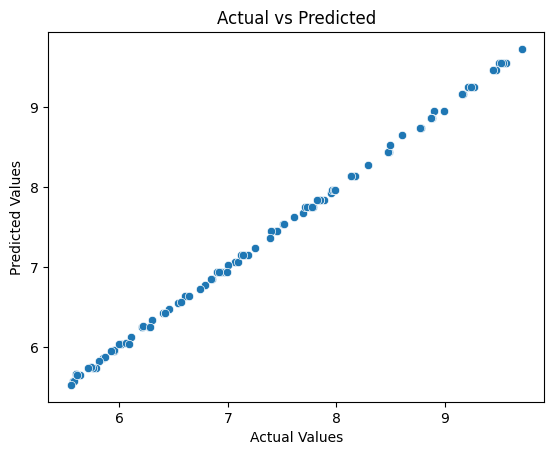

In [26]:
import matplotlib.pyplot as plt

sns.scatterplot(x=Y_test, y=Y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

In [27]:
import pickle

# Save the model
with open("linear_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as linear_regression_model.pkl")

Model saved as linear_regression_model.pkl


<Axes: xlabel='current_sem_CGPA'>

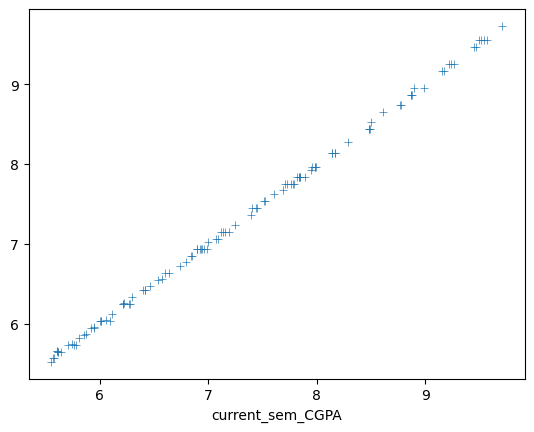

In [28]:
sns.scatterplot(x=Y_test, y=Y_pred, marker="+")

['Age', 'Gender', 'daily_screen_time_hours', 'social_media_hours', 'online_study_hours', 'gaming_hours', 'sleep_hours', 'attendance_percentage', 'offline_study_hours']


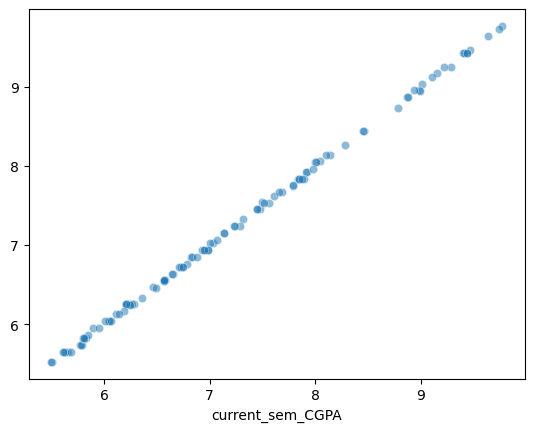

In [25]:
sns.scatterplot(x=Y_test, y=Y_pred, alpha=0.5)
print(X.columns.tolist())